In [32]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [62]:
outputpath = "/data/users4/xli/MISA/MISA-pytorch/runs/BHI25"
# dir_list = os.listdir(outputpath)

seed_list = [7, 14, 21]

# Significant models and their labels
# model_list = ['lr0.007_bs200_ab1-0.95_ab2-0.87', 'lr0.0265_bs316_ab1-0.95_ab2-0.81', 'lr0.1_bs200_ab1-0.919_ab2-0.81', 'combined_significant_model']
# model_label_list = [2,4,6,7]

# Full models and their labels
model_list = ['lr0.0093_bs316_ab1-0.9233_ab2-0.87', 'lr0.029_bs316_ab1-0.95_ab2-0.8484', 'lr0.1_bs200_ab1-0.899_ab2-0.8154', 'combined_full_model']
model_label_list = [1,3,5,7]

loss_all = []
isi_all = []
label_all = []

for j, params in enumerate(model_list):
    for seed in seed_list:
        datapath = os.path.join(outputpath, params, f"res_sim-siva_dataset100_source12_sample32768_seed{seed}_wpca.p")
        res = pickle.load(open(datapath, "rb"))

        loss = res['loss'][0]
        isi = res['MISI'][0]

        loss_mean = np.zeros(len(loss))
        for i in range(len(loss)):
            loss_mean[i] = np.mean(loss[i])
        isi_mean = np.array(isi)
        loss_all.append(loss_mean)
        isi_all.append(isi_mean)
        label_all.append(f"Setting {model_label_list[j]}, Seed {seed}")

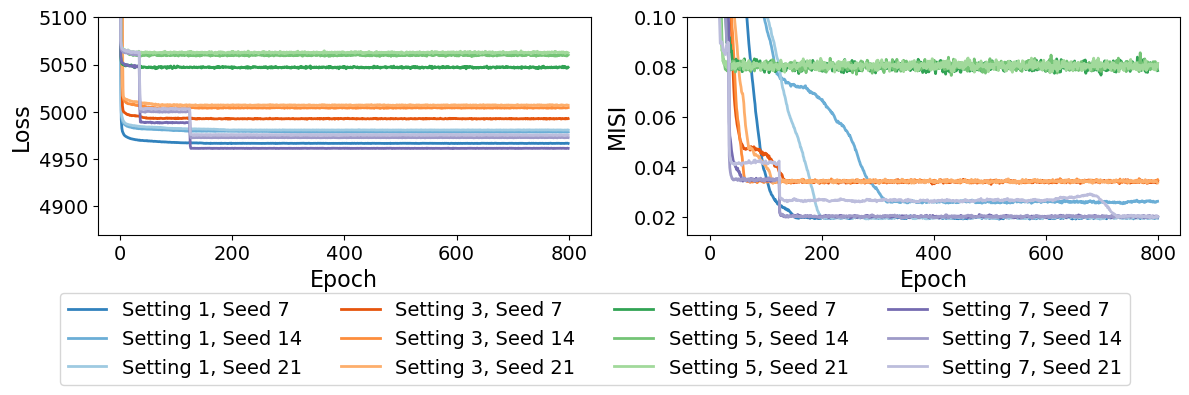

In [63]:
n_epoch = 800
color_indices = [0, 1, 2, 4, 5, 6, 8, 9, 10, 12, 13, 14]
# color_indices = [1, 5, 9, 2, 6, 10, 3, 7, 11, 0, 4, 8]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

min_all = [np.min(la) for la in loss_all]
max_all = [np.max(la) for la in loss_all]
for i, l in enumerate(label_all):
    axes[0].plot(range(n_epoch), loss_all[i], label=l, linewidth=2, color=plt.cm.tab20c(color_indices[i]))
    # axes[0].plot(range(n_epoch), np.log10(loss_all[i]-min(min_all)+1e0)+1, label=l, linewidth=2, color=plt.cm.tab20c(color_indices[i]))
    # axes[0].plot(range(n_epoch), np.log10(loss_all[i]-np.min(loss_all[i])+1)+1, label=l, linewidth=1, color=plt.cm.tab20c(color_indices[i]))
axes[0].set_xlabel("Epoch", fontsize=16)
axes[0].set_ylabel("Loss", fontsize=16)
axes[0].tick_params(axis='both', which='major', labelsize=14)
# axes[0].set_ylim(4950, 5075) # Full models
axes[0].set_ylim(4870, 5100)
# axes[0].set_ylim(0.95, np.log10(max(max_all) - min(min_all) + 1e0) + 1.2)
# axes[0].set_ylim(0.95, 3.5)

for i, l in enumerate(label_all):
    axes[1].plot(range(n_epoch), isi_all[i], label=l, linewidth=2, color=plt.cm.tab20c(color_indices[i]))
axes[1].set_xlabel("Epoch", fontsize=16)
axes[1].set_ylabel("MISI", fontsize=16)
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].set_ylim(0.013, 0.1)
# axes[1].set_yscale("log")
# axes[1].legend(fontsize=10, bbox_to_anchor=(1, 1.05))
handles, labels = axes[1].get_legend_handles_labels()
# Create legend on the figure using only those handles and labels
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), fontsize=14, ncol=4)

# Adjust layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.4)  # Add space at the bottom
# plt.savefig("/data/users4/xli/MISA/MISA-pytorch/runs/BHI25/significant_model_loss_isi.pdf")#, dpi=500
# plt.savefig("/data/users4/xli/MISA/MISA-pytorch/runs/BHI25/full_model_loss_isi.pdf")#, dpi=500
plt.savefig("/data/users3/rsilva/MISA-pytorch/figures/yohan3b.pdf", bbox_inches='tight', dpi=800 )#, dpi=500
# plt.savefig("/data/users3/rsilva/MISA-pytorch/figures/significant_model_loss_isi_final.pdf", bbox_inches='tight', dpi=800 )#, dpi=500